# 05.01 · Regresión lineal y logística

**Objetivo:** entender el modelo más simple que existe — una suma ponderada de las
entradas — en sus dos versiones: la que predice **un número** (lineal) y la que predice
**una clase** (logística).

Es el punto de partida obligatorio: una neurona sin capas ocultas *es* exactamente una
regresión logística. Si entiendes este cuaderno, ya entiendes la unidad básica de
cualquier red neuronal.

📖 Teoría: [5.1 Modelos clásicos](../../../../../docs/02-deep-learning/05-tipos-de-modelo/5.1-modelos-clasicos.md)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from dllab import set_seed

set_seed(42)


def euros(x: float) -> str:
    """Formatea un número como euros con separador de miles español."""
    return f"{x:,.0f} €".replace(",", ".")

---
# Parte A · Regresión lineal — predecir un número

## 1. El caso de uso

Eres tasador en una inmobiliaria. Te llega un piso de 95 m² y tienes que decir por
cuánto se puede vender. Tienes una libreta con **200 ventas anteriores**: metros
cuadrados y precio final de cada una.

La pregunta es: *¿puedo dibujar una recta que resuma esas 200 ventas y usarla para
el piso nuevo?*

## 2. La idea en una frase

**Traza la recta que pasa lo más cerca posible de todos los puntos.**

La recta es `precio = w · metros + b`. Ajustar el modelo consiste en buscar los dos
números `w` y `b` que hacen mínima la suma de los errores al cuadrado — de ahí el
nombre "mínimos cuadrados".

- `w` (la **pendiente**) responde: *¿cuánto sube el precio por cada m² extra?*
- `b` (la **ordenada en el origen**) es el punto de partida, el precio "base".

## 3. Los datos

Los fabricamos nosotros para poder hacer trampa: **conocemos la respuesta correcta**.
Ponemos un precio real de 1.500 €/m² más una base de 30.000 €, y le sumamos ruido
(reformas, orientación, el regateo del comprador... todo lo que la superficie no explica).

Al final compararemos lo que el modelo ha aprendido con la verdad que escondimos.

In [3]:
PENDIENTE_REAL = 1_500.0   # € por m²
BASE_REAL = 30_000.0       # € de precio base
RUIDO = 25_000.0           # desviación típica del ruido, en €

rng = np.random.default_rng(42)
metros = rng.uniform(40, 160, size=200)
precio = PENDIENTE_REAL * metros + BASE_REAL + rng.normal(0, RUIDO, size=200)

# scikit-learn siempre espera X con forma (n_muestras, n_variables)
X = metros.reshape(-1, 1)
y = precio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"{len(X_train)} pisos para aprender, {len(X_test)} para examinarnos")

150 pisos para aprender, 50 para examinarnos


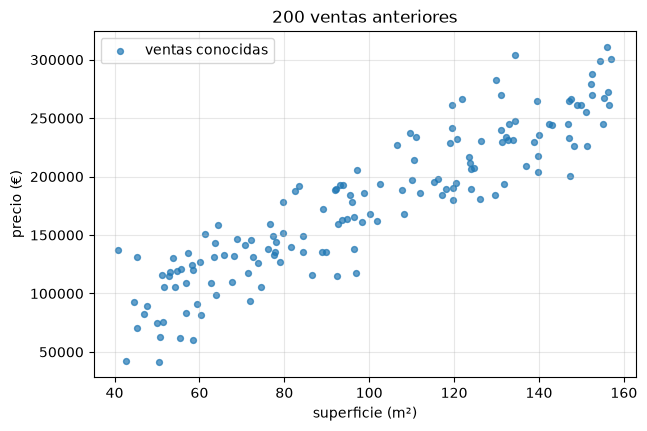

In [4]:
plt.figure(figsize=(7, 4.5))
plt.scatter(X_train, y_train, s=18, alpha=0.7, label="ventas conocidas")
plt.xlabel("superficie (m²)")
plt.ylabel("precio (€)")
plt.title("200 ventas anteriores")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Entrenar

Tres líneas. `fit` es donde ocurre todo: busca la mejor recta.

In [5]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

w = modelo.coef_[0]
b = modelo.intercept_

print(f"El modelo ha aprendido:  {euros(w)} por m²  +  {euros(b)} de base")
print(f"La verdad escondida era: {euros(PENDIENTE_REAL)} por m²  +  {euros(BASE_REAL)} de base")
print(f"\nError en la pendiente: {abs(w - PENDIENTE_REAL) / PENDIENTE_REAL:.0%}")
print(f"Error en la base     : {abs(b - BASE_REAL) / BASE_REAL:.0%}")

El modelo ha aprendido:  1.643 € por m²  +  13.790 € de base
La verdad escondida era: 1.500 € por m²  +  30.000 € de base

Error en la pendiente: 10%
Error en la base     : 54%


La **pendiente** la ha recuperado bastante bien: unos 1.640 €/m² frente a los 1.500
reales. La **base**, en cambio, se aleja mucho — y eso merece una explicación, porque
es un error que se comete a diario.

La base es el precio de un piso de **0 m²**, y en nuestros datos no hay ningún piso de
menos de 40 m². El modelo está extrapolando a una zona de la que no tiene ni un solo
ejemplo, así que ese número es prácticamente una invención. Además, pendiente y base se
compensan entre sí: si la recta sube un poco más de la cuenta, tiene que arrancar más
abajo para seguir pasando por la nube de puntos.

**La moraleja:** un coeficiente solo significa algo dentro del rango de datos que has
visto. Fuera de él, el modelo no sabe nada — aunque te devuelva un número con toda la
seguridad del mundo.

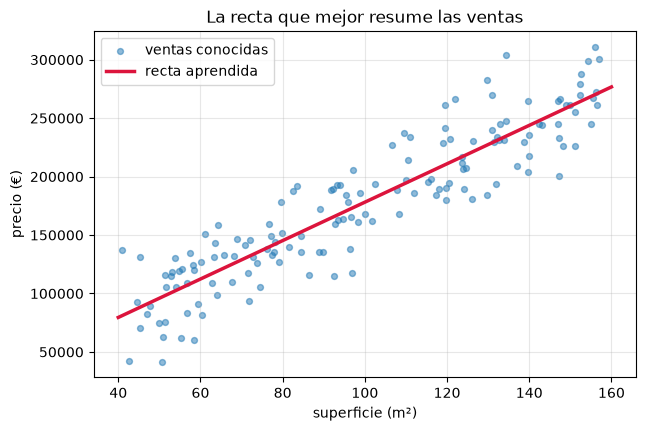

In [6]:
plt.figure(figsize=(7, 4.5))
plt.scatter(X_train, y_train, s=18, alpha=0.5, label="ventas conocidas")
linea = np.linspace(40, 160, 100).reshape(-1, 1)
plt.plot(linea, modelo.predict(linea), color="crimson", lw=2.5, label="recta aprendida")
plt.xlabel("superficie (m²)")
plt.ylabel("precio (€)")
plt.title("La recta que mejor resume las ventas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. ¿Acierta?

Lo medimos sobre los 50 pisos que el modelo **no ha visto nunca**. Dos métricas:

- **MAE** (error absoluto medio): de media, ¿cuántos euros me equivoco?
- **R²**: qué fracción de la variación de los precios explica la superficie.
  1,0 sería perfecto; 0,0 sería no explicar nada.

In [7]:
y_pred = modelo.predict(X_test)

print(f"MAE: {euros(mean_absolute_error(y_test, y_pred))}")
print(f"R² : {r2_score(y_test, y_pred):.3f}")

MAE: 19.041 €
R² : 0.812


El error se queda en torno a los 19.000 € y no baja por mucho que entrenemos. No es
culpa del modelo: es el **ruido que metimos a propósito** (25.000 € de desviación
típica). Ninguna recta puede predecir el regateo del comprador a partir de los metros
cuadrados. Buen recordatorio de que parte del error de cualquier modelo es simplemente
irreducible: hay un suelo por debajo del cual no se puede bajar.

In [8]:
# El piso de 95 m² que teníamos que tasar
piso_nuevo = np.array([[95.0]])
print(f"Tasación para 95 m²: {euros(modelo.predict(piso_nuevo)[0])}")

Tasación para 95 m²: 169.892 €


## 6. Más de una variable

Nada cambia si añadimos la antigüedad del piso: la recta se convierte en un **plano**,
y en lugar de un `w` tenemos uno por variable. La fórmula sigue siendo una suma
ponderada: `precio = w₁·metros + w₂·antigüedad + b`.

In [9]:
antiguedad = rng.uniform(0, 60, size=200)  # años
precio_2v = (
    PENDIENTE_REAL * metros - 800.0 * antiguedad + BASE_REAL + rng.normal(0, RUIDO, size=200)
)

X2 = np.column_stack([metros, antiguedad])
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, precio_2v, test_size=0.25, random_state=42)

modelo_2v = LinearRegression().fit(X2_train, y2_train)

for nombre, coef in zip(["por cada m²", "por cada año de antigüedad"], modelo_2v.coef_):
    print(f"{nombre:28} {euros(coef):>12}")
print(f"{'base':28} {euros(modelo_2v.intercept_):>12}")
print(f"\nR² en test: {modelo_2v.score(X2_test, y2_test):.3f}")

por cada m²                       1.645 €
por cada año de antigüedad         -883 €
base                             15.271 €

R² en test: 0.761


El coeficiente de la antigüedad sale **negativo**: cada año que pasa resta unos 800 €.
Los coeficientes de una regresión lineal se leen así de directamente, y por eso este
modelo sigue usándose donde hay que justificar una decisión ante alguien.

---
# Parte B · Regresión logística — predecir una clase

## 7. El caso de uso

Cambiamos de pregunta. Ya no queremos un número, queremos un **sí o un no**.

Un laboratorio analiza una biopsia y mide 30 características de las células (radio
medio, textura, simetría...). La pregunta: **¿el tumor es benigno o maligno?**

Usamos un conjunto real y clásico, el *Breast Cancer Wisconsin*, que viene incluido en
scikit-learn.

In [10]:
datos = load_breast_cancer()
X_c, y_c = datos.data, datos.target

print(f"{X_c.shape[0]} biopsias, {X_c.shape[1]} mediciones por biopsia")
print(f"Etiquetas: 0 = {datos.target_names[0]}, 1 = {datos.target_names[1]}")
print(f"Reparto: {np.bincount(y_c)[0]} malignos, {np.bincount(y_c)[1]} benignos")

569 biopsias, 30 mediciones por biopsia
Etiquetas: 0 = malignant, 1 = benign
Reparto: 212 malignos, 357 benignos


## 8. La idea en una frase

**Calcula la misma suma ponderada de antes, y luego aplástala entre 0 y 1 para
leerla como una probabilidad.**

Esa función que aplasta es la **sigmoide**: `σ(z) = 1 / (1 + e^(-z))`. Convierte
cualquier número real en algo entre 0 y 1.

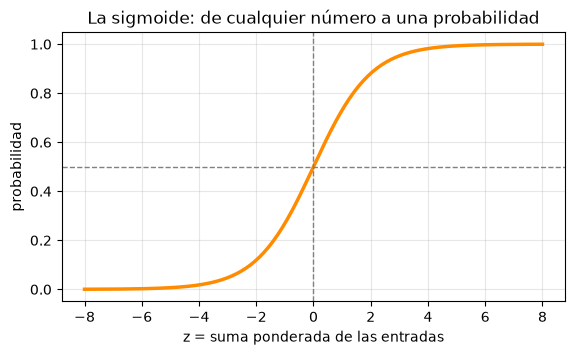

In [11]:
z = np.linspace(-8, 8, 200)
sigmoide = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6.5, 3.5))
plt.plot(z, sigmoide, lw=2.5, color="darkorange")
plt.axhline(0.5, ls="--", c="grey", lw=1)
plt.axvline(0, ls="--", c="grey", lw=1)
plt.xlabel("z = suma ponderada de las entradas")
plt.ylabel("probabilidad")
plt.title("La sigmoide: de cualquier número a una probabilidad")
plt.grid(alpha=0.3)
plt.show()

Cuando `z` es muy negativo la probabilidad tiende a 0; cuando es muy positivo, a 1.
El umbral habitual está en 0,5, justo donde `z = 0`.

**Aquí está el puente con el deep learning:** esto —suma ponderada + sigmoide— es
literalmente una neurona artificial. Una red neuronal no es más que muchas de estas
apiladas en capas.

## 9. Entrenar

Un paso extra respecto a la parte A: **escalar las variables**. Los radios se miden en
unidades muy distintas de las áreas, y sin escalar, el algoritmo de optimización
avanza a trompicones.

In [12]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

escalador = StandardScaler().fit(Xc_train)
Xc_train_esc = escalador.transform(Xc_train)
Xc_test_esc = escalador.transform(Xc_test)

clasificador = LogisticRegression(max_iter=5000)
clasificador.fit(Xc_train_esc, yc_train)

yc_pred = clasificador.predict(Xc_test_esc)
print(f"Acierto en test: {accuracy_score(yc_test, yc_pred):.1%}")

Acierto en test: 98.6%


## 10. ¿Dónde se equivoca?

El porcentaje de acierto esconde lo importante. Aquí los dos errores **no cuestan lo
mismo**: mandar a casa a alguien con un tumor maligno es mucho peor que asustar a
alguien con un tumor benigno. La matriz de confusión los separa.

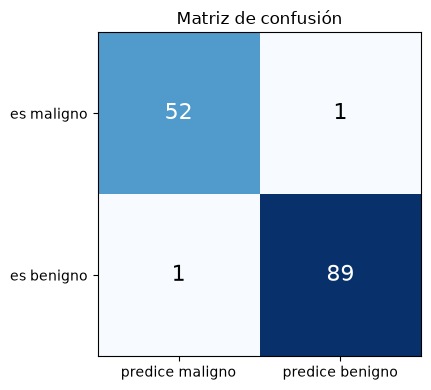

Malignos que se nos escapan: 1


In [13]:
cm = confusion_matrix(yc_test, yc_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["predice maligno", "predice benigno"])
ax.set_yticks([0, 1], ["es maligno", "es benigno"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

falsos_negativos = cm[0, 1]  # es maligno pero predice benigno
print(f"Malignos que se nos escapan: {falsos_negativos}")

## 11. Mirar por dentro: la probabilidad, no solo la etiqueta

Una ventaja enorme de este modelo frente a otros: no dice solo "benigno", dice
**"benigno con un 97 % de confianza"**. Eso permite derivar a revisión humana los
casos dudosos en lugar de tratarlos igual que los claros.

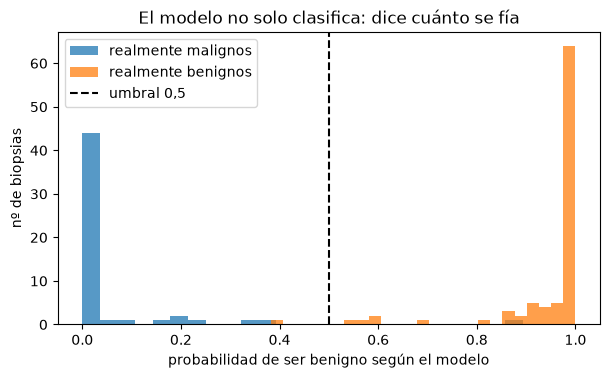

Casos en la zona dudosa (0,2–0,8): 9 de 143


In [14]:
probabilidades = clasificador.predict_proba(Xc_test_esc)[:, 1]  # P(benigno)

plt.figure(figsize=(7, 3.8))
plt.hist(probabilidades[yc_test == 0], bins=25, alpha=0.75, label="realmente malignos")
plt.hist(probabilidades[yc_test == 1], bins=25, alpha=0.75, label="realmente benignos")
plt.axvline(0.5, ls="--", c="k", lw=1.5, label="umbral 0,5")
plt.xlabel("probabilidad de ser benigno según el modelo")
plt.ylabel("nº de biopsias")
plt.title("El modelo no solo clasifica: dice cuánto se fía")
plt.legend()
plt.show()

dudosos = np.sum((probabilidades > 0.2) & (probabilidades < 0.8))
print(f"Casos en la zona dudosa (0,2–0,8): {dudosos} de {len(probabilidades)}")

La mayoría de los casos están pegados a 0 o a 1: el modelo lo tiene clarísimo. Los
pocos del centro son exactamente los que un médico querría revisar.

## 12. Qué mediciones pesan más

Como el modelo es una suma ponderada y hemos escalado las variables, los coeficientes
son directamente comparables entre sí.

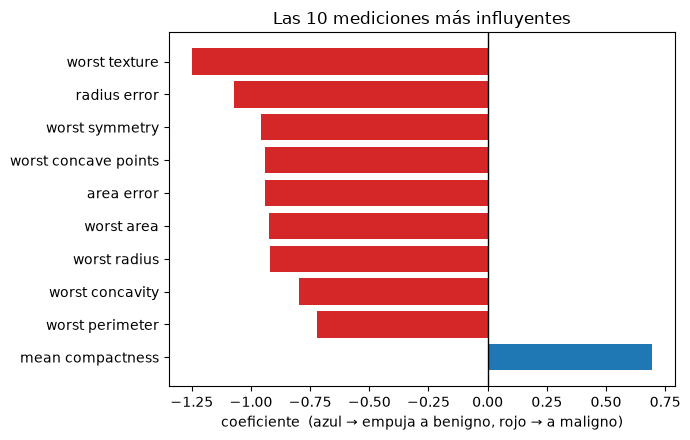

In [15]:
coeficientes = clasificador.coef_[0]
orden = np.argsort(np.abs(coeficientes))[-10:]

plt.figure(figsize=(7, 4.5))
colores = ["tab:red" if c < 0 else "tab:blue" for c in coeficientes[orden]]
plt.barh([datos.feature_names[i] for i in orden], coeficientes[orden], color=colores)
plt.axvline(0, c="k", lw=1)
plt.xlabel("coeficiente  (azul → empuja a benigno, rojo → a maligno)")
plt.title("Las 10 mediciones más influyentes")
plt.tight_layout()
plt.show()

## 13. Cuándo usarlo y cuándo no

**Úsalo cuando:**

- Necesitas **explicar** la decisión (un coeficiente es una frase: "cada m² suma 1.500 €").
- Tienes pocos datos: con 200 filas una red neuronal se aprende el ruido, esto no.
- Quieres una **línea base honesta**. Es la primera cosa que hay que probar, siempre.
  Si tu modelo sofisticado no bate a una logística, el modelo sofisticado no sirve.

**No lo uses cuando:**

- La relación es claramente curva o hay interacciones entre variables (una recta no
  puede capturarlas) → mira [SVM con kernel](05_02_svm_y_kernels.py) o
  [árboles](05_04_arbol_de_decision.py).
- Los datos son imágenes, audio o texto largo: ahí las redes profundas ganan de calle.

## 14. Prueba tú

1. Sube `RUIDO` a 80.000 y vuelve a ejecutar la parte A. ¿Sigue recuperando los
   1.500 €/m²? ¿Qué le pasa al R²?
2. En la parte B, quédate solo con las 2 primeras columnas de `X_c`
   (`X_c[:, :2]`). ¿Cuánto acierto pierdes usando 2 mediciones en vez de 30?
3. Baja el umbral de decisión a 0,3 (`(probabilidades > 0.3).astype(int)`) y recalcula
   la matriz de confusión. ¿Se escapan menos malignos? ¿A cambio de qué?